In [1]:
import numpy as np
import matplotlib
import os
import pyvista as pv

from matplotlib import pyplot as plt
from matplotlib.collections import PolyCollection
from pathlib import Path
from matplotlib.colors import Normalize

/home/zeping/anaconda3/envs/jax_fea/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
case_IGFEM = '1fib_t500'
case_JAX = 'nonlinear_IGFEM_vmap_t500_1fib'
path = os.path.join(os.getcwd(),'tests','output')
IGFEM_path =  os.path.join(path,case_IGFEM)
JAX_path =  os.path.join(path,case_JAX,'vtks')


feature = 'damage' # ['e11', 'e22', 'e12','s11','s22','s12','damage']
t_end = 500

cell = 422

feature_IGFEM = []
feature_JAX   = []
s11_IGFEM,s11_JAX = [],[]
s22_IGFEM,s22_JAX = [],[]
s12_IGFEM,s12_JAX = [],[]
e11_IGFEM,e11_JAX = [],[]
e22_IGFEM,e22_JAX = [],[]
e12_IGFEM,e12_JAX = [],[]

for time in range(0,t_end+1):
    # IGFEM
    mesh_IGFEM = pv.read(IGFEM_path+f'/History.{time}.vtk')
    feature_IGFEM.append(mesh_IGFEM[feature])
    # JAX
    mesh_JAX = pv.read(JAX_path+f'/fea_solve_out_{time}.vtk')
    feature_JAX.append(mesh_JAX[feature])
    s11_JAX.append(mesh_JAX['s11'])
    s22_JAX.append(mesh_JAX['s22'])
    s12_JAX.append(mesh_JAX['s12'])
    e11_JAX.append(mesh_JAX['e11'])
    e22_JAX.append(mesh_JAX['e22'])
    e12_JAX.append(mesh_JAX['e12']) 
    s11_IGFEM.append(mesh_IGFEM['s11'])
    s22_IGFEM.append(mesh_IGFEM['s22'])
    s12_IGFEM.append(mesh_IGFEM['s12'])
    e11_IGFEM.append(mesh_IGFEM['e11'])
    e22_IGFEM.append(mesh_IGFEM['e22'])
    e12_IGFEM.append(mesh_IGFEM['e12'])
# Initialize mesh
points = mesh_JAX.points[:,:2]

# Go through the pyvista loop, which is absolute pain to do.
polygons = []
for id in range(len(mesh_JAX.celltypes)):
    nodes = mesh_JAX.get_cell(id).point_ids
    polygons.append(points[nodes])

feature_IGFEM = np.array(feature_IGFEM)
feature_JAX   = np.array(feature_JAX)

s11_JAX   = np.array(s11_JAX)
s22_JAX   = np.array(s22_JAX)
s12_JAX   = np.array(s12_JAX)
e11_JAX   = np.array(e11_JAX)
e22_JAX   = np.array(e22_JAX)
e12_JAX   = np.array(e12_JAX)

s11_IGFEM   = np.array(s11_IGFEM)
s22_IGFEM   = np.array(s22_IGFEM)
s12_IGFEM   = np.array(s12_IGFEM)
e11_IGFEM   = np.array(e11_IGFEM)
e22_IGFEM   = np.array(e22_IGFEM)
e12_IGFEM   = np.array(e12_IGFEM)

## only shows IGFEM and JAX features

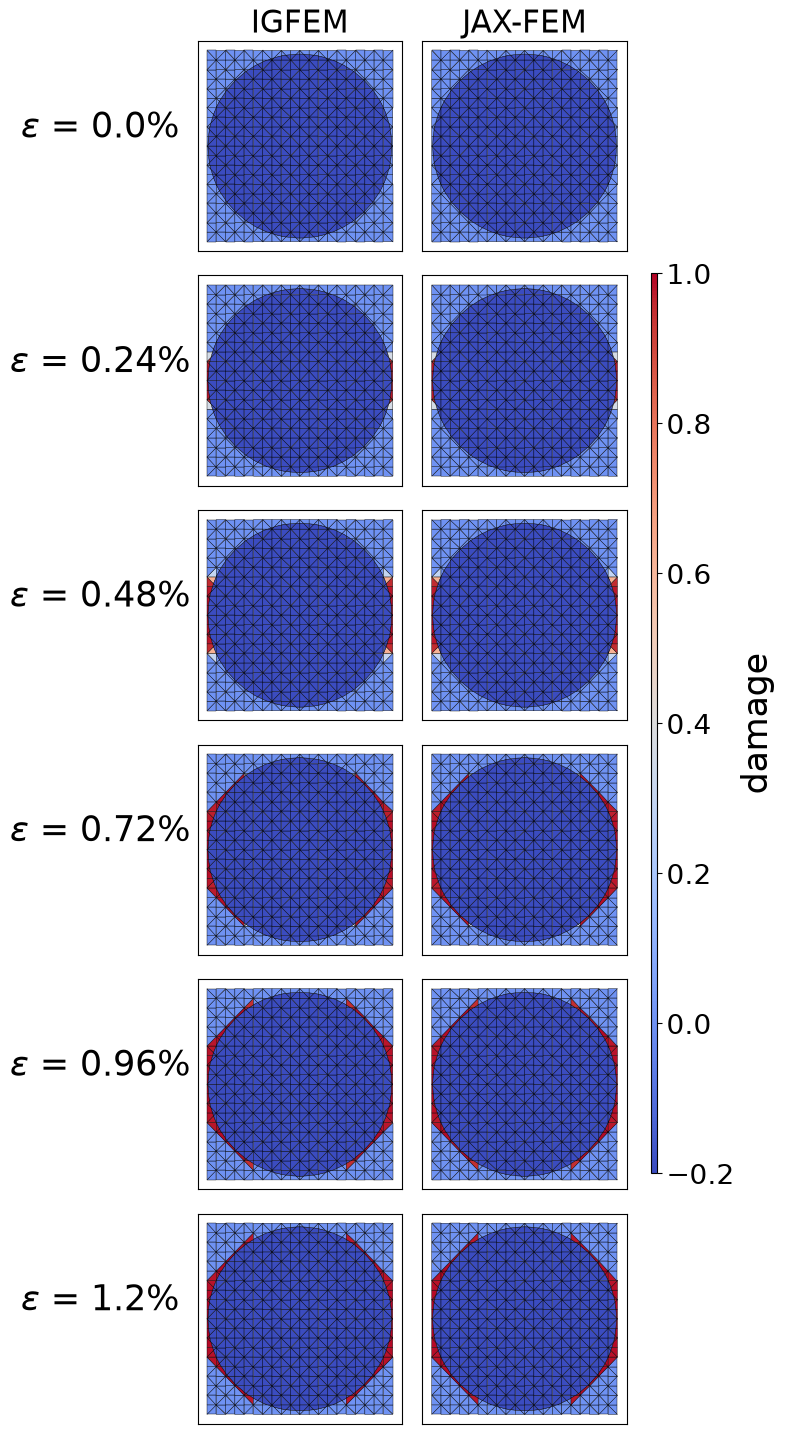

In [4]:
strain_rate = 0.012 / len(feature_JAX)

num_t = min(6,t_end)
total_time = len(feature_JAX)
# time_discret = np.round(np.linspace(0, total_time-1, num_t)).astype(int)
time_discret = [0,100,200,300,400,500]
# num_t = len(time_discret)
applied_strain = np.round(np.arange(total_time) * strain_rate * 100, 2)
applied_strain[0] = 0
applied_strain[-1] = 1.2

plot_label = feature_IGFEM
plot_out   = feature_JAX

if feature == 'damage':
    vmin=-0.2
    vmax=1
else:
# elif feature == 'damage':
    vmin=np.min(feature_IGFEM)
    vmax=np.max(feature_IGFEM)

norm = Normalize(vmin=vmin, vmax=vmax)

plt.close('all')
fig, ax = plt.subplots(num_t, 2, figsize=(6, 3 * num_t), gridspec_kw={'wspace': 0.1, 'hspace': 0.1})
for i, time in enumerate(time_discret):
    # Plot
    poly_IGFEM = PolyCollection(polygons,array=plot_label[time], edgecolors='k', cmap='coolwarm',linewidth=0.3,norm=norm)
    poly_JAX   = PolyCollection(polygons,array=plot_out[time], edgecolors='k', cmap='coolwarm',linewidth=0.3,norm=norm)
    plot_label_cbar = ax[i,0].add_collection(poly_IGFEM)
    ax[i,1].add_collection(poly_JAX)

    # Label
    ax[i, 0].set_ylabel(r'$\epsilon$ = ' + str(applied_strain[time]) + '%', fontsize=25, rotation=0, labelpad=70)

# Colorbar
phi_ax_s = fig.add_axes([0.88, 0.25, 0.01, 0.5])
cbarp_s = fig.colorbar(plot_label_cbar, cax=phi_ax_s)
cbarp_s.ax.tick_params(labelsize=20)
cbarp_s.set_label(feature, size=25)

# Titles
ax[0, 0].set_title('IGFEM',   fontsize=22)
ax[0, 1].set_title('JAX-FEM', fontsize=22)

# Ticks off
for ax_x in range(ax.shape[1]):
    for ax_y in range(ax.shape[0]):
        ax[ax_y, ax_x].set_aspect('equal')
        ax[ax_y, ax_x].set_xticks([])
        ax[ax_y, ax_x].set_yticks([])
        ax[ax_y, ax_x].autoscale()

fig.subplots_adjust(right=0.84)
plt.savefig(path+'/'+case_JAX+'/model_comparsion_'+feature+'.png',bbox_inches='tight', dpi=300)

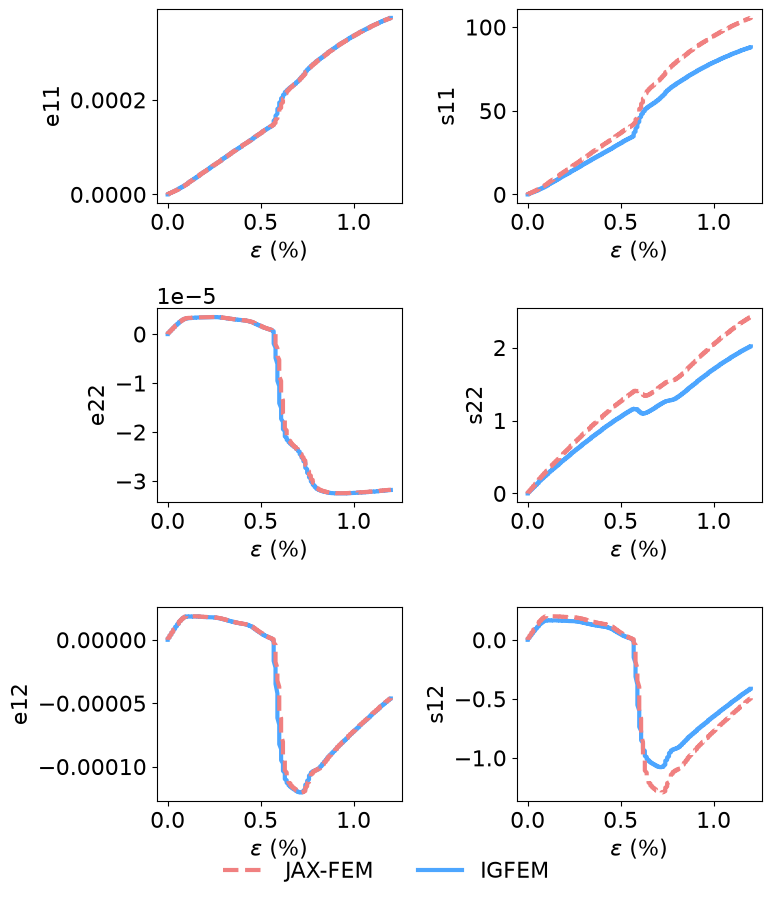

In [11]:
cell = 20
t_end = 501
color_IGFEM = '#4DA6FF'
color_JAX = '#F08080'
plt.rcParams['font.size'] = 16

# Create figure
plt.close('all')
fig, ax = plt.subplots(3, 2, figsize=(8,9)) #,gridspec_kw = {'wspace':0.5, 'hspace':0.5})

# Legend bottom-right
# leg = ax.legend()

def plot_sub(ax,x,feature_JAX,feature_IGFEM,ylabel):
    ax.plot(x,feature_JAX,'--',color=color_JAX,linewidth=3,label='JAX-FEM',zorder=1)
    ax.plot(x,feature_IGFEM,color=color_IGFEM,linewidth=3,label='IGFEM',zorder=0)
    ax.set_xlabel(r'$\epsilon$ (%)')
    ax.set_ylabel(ylabel)

plot_sub(ax[0,0],applied_strain[:t_end],e11_JAX[:t_end,cell],e11_IGFEM[:t_end,cell],'e11')
plot_sub(ax[1,0],applied_strain[:t_end],e22_JAX[:t_end,cell],e22_IGFEM[:t_end,cell],'e22')
plot_sub(ax[2,0],applied_strain[:t_end],e12_JAX[:t_end,cell],e12_IGFEM[:t_end,cell],'e12')
plot_sub(ax[0,1],applied_strain[:t_end],s11_JAX[:t_end,cell],s11_IGFEM[:t_end,cell],'s11')
plot_sub(ax[1,1],applied_strain[:t_end],s22_JAX[:t_end,cell],s22_IGFEM[:t_end,cell],'s22')
plot_sub(ax[2,1],applied_strain[:t_end],s12_JAX[:t_end,cell],s12_IGFEM[:t_end,cell],'s12')

# Collect handles and labels from one axis
handles, labels = ax[0,0].get_legend_handles_labels()

# Place legend at bottom center
fig.legend(handles, labels,
           loc='lower center',
           bbox_to_anchor=(0.5, -0.02),  # adjust vertical offset if needed
           ncol=2,                        # put entries side by side
           frameon=False)

fig.tight_layout()
plt.savefig(path+'/'+case_JAX+f'/{feature}_t.png',bbox_inches='tight',dpi=300)

## IGFEM, JAX, Error

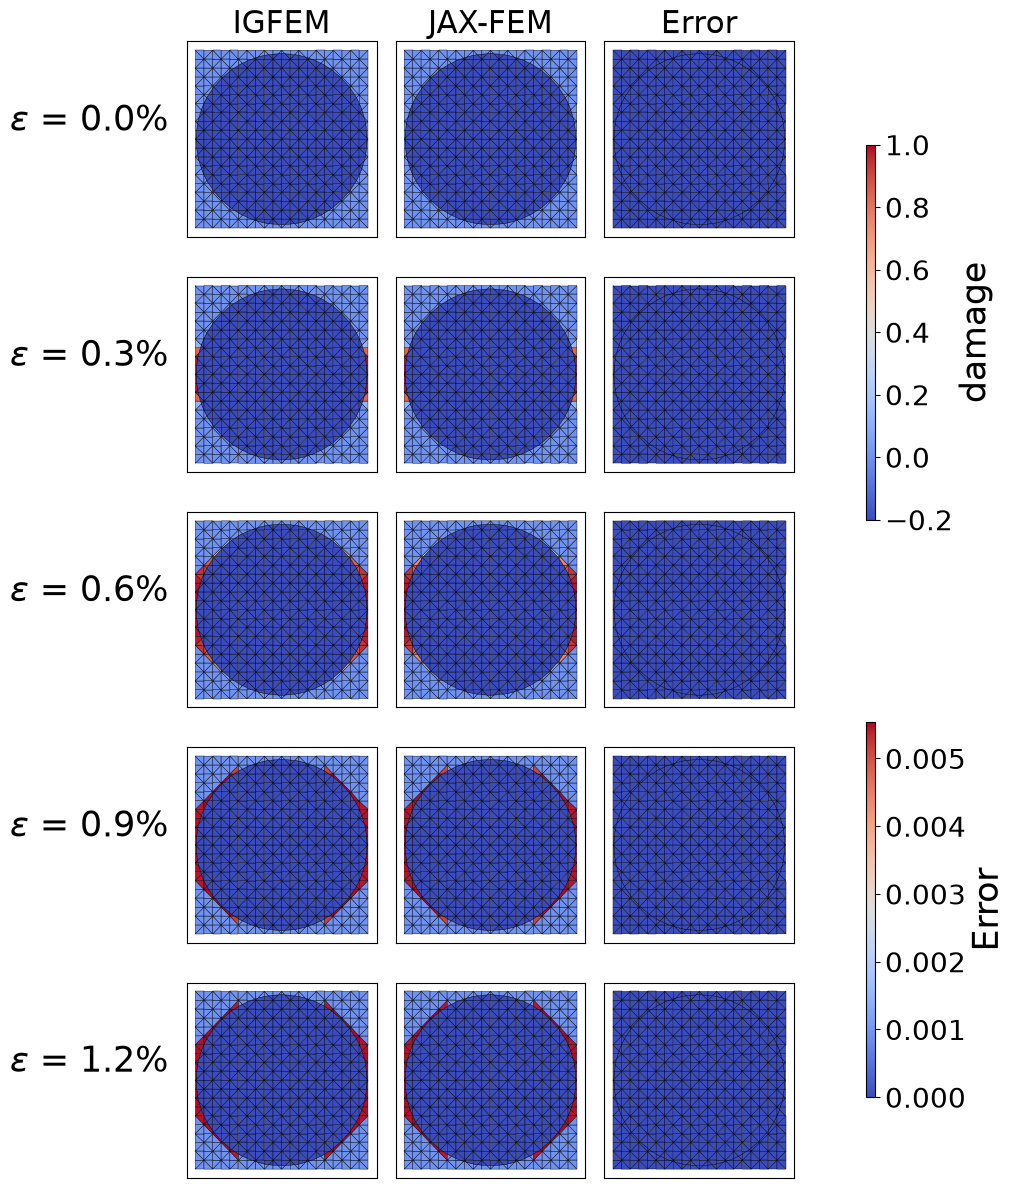

In [7]:
strain_rate = 0.012 / len(feature_IGFEM)

num_t = min(5,t_end+1)
total_time = len(feature_IGFEM)
time_discret = np.round(np.linspace(0, total_time-1, num_t)).astype(int)
applied_strain = np.round(np.arange(total_time+1) * strain_rate * 100, 2)
applied_strain[0] = 0
applied_strain[-1] = 1.2

plot_label = feature_IGFEM
plot_out   = feature_JAX
error = abs(plot_out - plot_label)

if feature == 'damage':
    vmin=-0.2
    vmax=1
    vmin_e=np.min(error)
    vmax_e=np.max(error)*1e-2
else:
# elif feature == 'damage':
    vmin=np.min(feature_IGFEM)
    vmax=np.max(feature_IGFEM)
    vmin_e=np.min(error)
    vmax_e=np.max(error)*1e-2


norm   = Normalize(vmin=vmin, vmax=vmax)
norm_e = Normalize(vmin=vmin_e, vmax=vmax_e)

# # Create colormap with masked value for fibers
# cmap = 'coolwarm'
# cmap_obj = plt.get_cmap(cmap)
# cmap_obj.set_bad(color='black')  # Color for fiber (-0.2) regions

plt.close('all')
fig, ax = plt.subplots(num_t, 3, figsize=(9, 3 * num_t), gridspec_kw={'wspace': 0.1, 'hspace': 0.1})
for i, time in enumerate(time_discret):
    # Plot
    poly_IGFEM = PolyCollection(polygons,array=plot_label[time], edgecolors='k', cmap='coolwarm',linewidth=0.3,norm=norm)
    poly_JAX   = PolyCollection(polygons,array=plot_out[time], edgecolors='k', cmap='coolwarm',linewidth=0.3,norm=norm)
    poly_error = PolyCollection(polygons,array=plot_out[time] - plot_label[time], edgecolors='k', cmap='coolwarm',linewidth=0.3,norm=norm_e)
    plot_label_feature = ax[i,0].add_collection(poly_IGFEM)
    ax[i,1].add_collection(poly_JAX)
    plot_label_error = ax[i,2].add_collection(poly_error)


    # Label
    ax[i, 0].set_ylabel(r'$\epsilon$ = ' + str(applied_strain[time]) + '%', fontsize=25, rotation=0, labelpad=70)

# Colorbar
phi_ax_s = fig.add_axes([0.88, 0.555, 0.01, 0.25])
cbarp_s = fig.colorbar(plot_label_feature, cax=phi_ax_s)
cbarp_s.ax.tick_params(labelsize=20)
cbarp_s.set_label(feature, size=25)
phi_ax_s = fig.add_axes([0.88, 0.17, 0.01, 0.25])

cbarp_e = fig.colorbar(plot_label_error, cax=phi_ax_s)
cbarp_e.ax.tick_params(labelsize=20)
cbarp_e.set_label('Error', size=25)

# Titles
ax[0, 0].set_title('IGFEM',   fontsize=22)
ax[0, 1].set_title('JAX-FEM', fontsize=22)
ax[0, 2].set_title('Error', fontsize=22)

# Ticks off
for ax_x in range(ax.shape[1]):
    for ax_y in range(ax.shape[0]):
        ax[ax_y, ax_x].set_aspect('equal')
        ax[ax_y, ax_x].set_xticks([])
        ax[ax_y, ax_x].set_yticks([])
        ax[ax_y, ax_x].autoscale()

fig.subplots_adjust(right=0.8)
plt.savefig(path+'/'+case_JAX+'/model_comparsion_'+feature+'.png',bbox_inches='tight', dpi=300)

## for 1 time

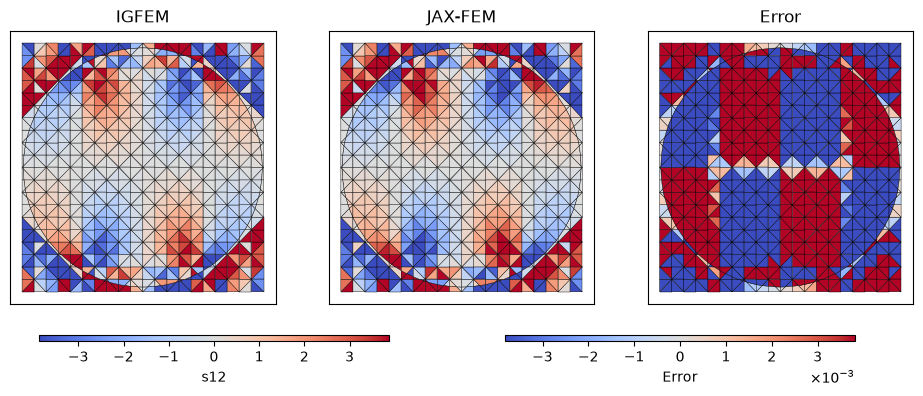

In [10]:
case_IGFEM = '1fib_t500'
case_JAX = 'nonlinear_IGFEM_vmap_t500_1fib'

# features = ['displacement', 'e11','e22', 'e12','s11','s22','s12','damage',]
features = ['s11','s22','s12']
# features = ['displacement','damage']
time = 500

path = os.path.join(os.getcwd(),'tests','output')
save_path = os.path.join(path,case_JAX,'1t_debug')
IGFEM_path =  os.path.join(path,case_IGFEM)
JAX_path =  os.path.join(path,case_JAX,'vtks')

os.makedirs(save_path, exist_ok=True)
plt.rcParams.update({'font.size': 10})

# Load Mesh
mesh_IGFEM = pv.read(IGFEM_path+f'/History.{time}.vtk')
mesh_JAX = pv.read(JAX_path+f'/fea_solve_out_{time}.vtk')

# Initialize mesh
points = mesh_IGFEM.points[:,:2]

# Go through the pyvista loop, which is absolute pain to do.
polygons = []
for id in range(len(mesh_IGFEM.celltypes)):
    nodes = mesh_IGFEM.get_cell(id).point_ids
    polygons.append(points[nodes])

for feature in features:
    if len(mesh_IGFEM[feature].shape) == 1:
        plot_label = mesh_IGFEM[feature]
        plot_out = mesh_JAX[feature]
    else:
        plot_label, plot_out = [], []
        for id in range(len(mesh_IGFEM.celltypes)):
            nodes = mesh_IGFEM.get_cell(id).point_ids
            plot_label.append(np.mean(mesh_IGFEM.point_data[feature][:,0][nodes]))
            plot_out.append(np.mean(mesh_JAX.point_data[feature][:,0][nodes]))

        plot_label = np.array(plot_label)
        plot_out = np.array(plot_out)
    error = plot_out - plot_label

    if feature == 'displacement':
        vmin, vmax = -1.1e-6, 8.5e-5
        err = np.max(abs(error))
        vmin_e=-err
        vmax_e=err

    elif feature == 'damage':
        vmin=-0.2
        vmax=1
        err = np.max(abs(error))*1e-2
        vmin_e=-5e-6
        vmax_e=5e-6
    elif feature in ['s11','s22','s12']:
        if feature == 's11':
            vmin=np.min(plot_label)
            vmax=np.max(plot_label)
            err = np.max(abs(error))*1e-2
        else:
            vmin=np.min(plot_label)*1e-1
            vmax=np.max(plot_label)*1e-1
            err = np.max(abs(error))*1e-3
        vmin_e=-err
        vmax_e=err
    elif feature in ['e11','e22','e12']:
        if feature == 'e11':
            vmin=np.min(plot_label)
            vmax=np.max(plot_label)
            err = np.max(abs(error))*1e-2
        else:
            vmin=np.min(plot_label)*1e-1
            vmax=np.max(plot_label)*1e-1
            err = np.max(abs(error))*1e-3
        vmin_e=-err
        vmax_e=err
    else:
        vmin=np.min(plot_label)
        vmax=np.max(plot_label)
        vmin_e=-np.max(abs(error))*1e-4
        vmax_e=np.max(abs(error))*1e-4

    norm   = Normalize(vmin=vmin, vmax=vmax)
    norm_e = Normalize(vmin=vmin_e, vmax=vmax_e)

    # # Create colormap with masked value for fibers
    # cmap = 'coolwarm'
    # cmap_obj = plt.get_cmap(cmap)
    # cmap_obj.set_bad(color='black')  # Color for fiber (-0.2) regions

    plt.close('all')
    xy_ratio = (mesh_JAX.bounds[1]-mesh_JAX.bounds[0]) / (mesh_JAX.bounds[3]-mesh_JAX.bounds[2])
    fig, ax = plt.subplots(1, 3, figsize=(12 * xy_ratio, 6))
    time=1
    # Plot
    poly_IGFEM = PolyCollection(polygons,array=plot_label, edgecolors='k', cmap='coolwarm',linewidth=0.3,norm=norm)
    poly_JAX   = PolyCollection(polygons,array=plot_out, edgecolors='k', cmap='coolwarm',linewidth=0.3,norm=norm)
    poly_error = PolyCollection(polygons,array=error, edgecolors='k', cmap='coolwarm',linewidth=0.3,norm=norm_e)
    plot_label_feature = ax[0].add_collection(poly_IGFEM)
    ax[1].add_collection(poly_JAX)
    plot_label_error = ax[2].add_collection(poly_error)


    # Label
    # ax[0].set_ylabel(r'$\epsilon$ = ' + str(applied_strain[time]) + '%', fontsize=25, rotation=0, labelpad=70)

    # Colorbar
    phi_ax_s = fig.add_axes([0.15, 0.2, 0.3, 0.01])
    cbarp_s = fig.colorbar(plot_label_feature, cax=phi_ax_s, orientation="horizontal")
    cbarp_s.formatter.set_powerlimits((0, 0))
    cbarp_s.formatter.set_useMathText(True)
    cbarp_s.set_label(feature)

    phi_ax_e = fig.add_axes([0.55, 0.2, 0.3, 0.01])
    cbarp_e = fig.colorbar(plot_label_error, cax=phi_ax_e, orientation="horizontal")
    cbarp_e.set_label('Error')
    # Force scientific notation
    cbarp_e.formatter.set_powerlimits((0, 0))
    cbarp_e.formatter.set_useMathText(True)

    # Titles
    ax[0].set_title('IGFEM')
    ax[1].set_title('JAX-FEM')
    ax[2].set_title('Error')

    # Ticks off
    for ax_y in range(ax.shape[0]):
        ax[ax_y].set_aspect('equal')
        ax[ax_y].set_xticks([])
        ax[ax_y].set_yticks([])
        ax[ax_y].autoscale()
    
    fig.subplots_adjust(bottom=0.1)
    plt.savefig(os.path.join(save_path,feature+'.png'),bbox_inches='tight', dpi=300)